In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving mtcars.csv to mtcars.csv


In [5]:
df = pd.read_csv('/content/mtcars.csv')

In [6]:
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [7]:
df.isnull().sum()

,0
model,0
mpg,0
cyl,0
disp,0
hp,0
drat,0
wt,0
qsec,0
vs,0
am,0


In [8]:
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [9]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print(f"DataFrame shape before removing duplicates: {df.shape}")
    df.drop_duplicates(inplace=True)
    print(f"DataFrame shape after removing duplicates: {df.shape}")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


In [10]:
df.nunique()

,0
model,32
mpg,25
cyl,3
disp,27
hp,22
drat,22
wt,29
qsec,30
vs,2
am,2


In [11]:
y = df['mpg']
X = df.drop('mpg', axis=1)

In [12]:
from sklearn.model_selection import train_test_split

X_numeric = X.drop('model', axis=1, errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)

print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(25, 10), y_train=(25,)
Testing set shape: X_test=(7, 10), y_test=(7,)


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


Mean Squared Error (MSE): 10.13
R-squared (R2): 0.75


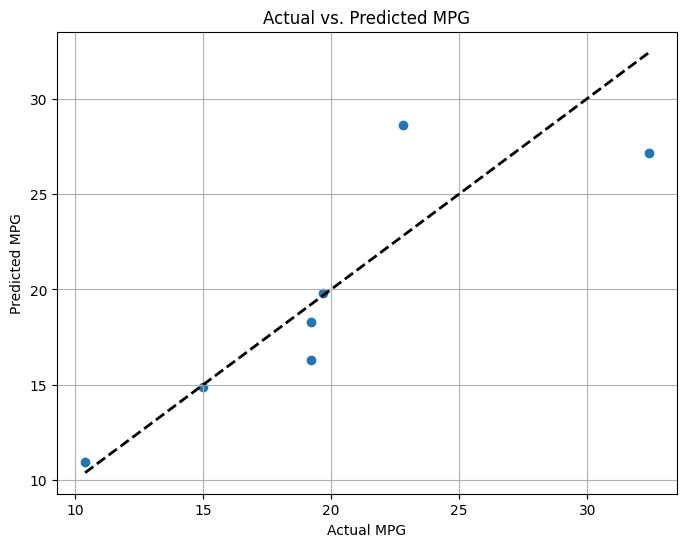

In [14]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs. Predicted MPG")
plt.grid(True)
plt.show()

In [15]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"\n--- Ridge Regression ---")
print(f"Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"R-squared (R2): {r2_ridge:.2f}")

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"\n--- Lasso Regression ---")
print(f"Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"R-squared (R2): {r2_lasso:.2f}")

elastic_net_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net_model.fit(X_train, y_train)
y_pred_elastic_net = elastic_net_model.predict(X_test)

mse_elastic_net = mean_squared_error(y_test, y_pred_elastic_net)
r2_elastic_net = r2_score(y_test, y_pred_elastic_net)

print(f"\n--- Elastic Net Regression ---")
print(f"Mean Squared Error (MSE): {mse_elastic_net:.2f}")
print(f"R-squared (R2): {r2_elastic_net:.2f}")


--- Ridge Regression ---
Mean Squared Error (MSE): 6.84
R-squared (R2): 0.83

--- Lasso Regression ---
Mean Squared Error (MSE): 7.18
R-squared (R2): 0.82

--- Elastic Net Regression ---
Mean Squared Error (MSE): 7.14
R-squared (R2): 0.82
